In [1]:
%pip install ultralytics -q
import os, yaml, shutil, random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO

# Official RDD2022 dataset location in Kaggle
dataset_src = '/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train' 
working_dir = '/kaggle/working/VisionRoad_Final'

# Official RDD2022 Mapping -> Your VisionRoad Indices
# D00: 0, D10: 1, D20: 2, D40: 3
mapping = {
    '0': '0', # D00 - Longitudinal
    '1': '1', # D10 - Transverse
    '2': '2', # D20 - Alligator
    '8': '3'  # D40 - Pothole (In many RDD sets, D40 is index 8)
}
class_names = {0: 'Longitudinal', 1: 'Transverse', 2: 'Alligator', 3: 'Pothole'}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
# Create directory structure
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(working_dir, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(working_dir, split, 'labels'), exist_ok=True)

image_files = [f for f in os.listdir(os.path.join(dataset_src, 'images')) if f.endswith('.jpg')]
random.seed(42)
random.shuffle(image_files)

# Split indices
total = len(image_files)
train_end, val_end = int(total * 0.7), int(total * 0.9)

# Adaptive Mapping: Based on your logs, we need to map 0, 1, 2, and the pothole index
# In this specific Kaggle set, D40 (Pothole) is usually index '3'
mapping = {'0': '0', '1': '1', '2': '2', '3': '3'} 

stats = []
print("🚀 Re-Splitting and Purging Ghost Classes...")

for i, fname in enumerate(image_files):
    split = 'train' if i < train_end else ('val' if i < val_end else 'test')
    label_fname = fname.replace('.jpg', '.txt')
    src_label = os.path.join(dataset_src, 'labels', label_fname)
    
    if os.path.exists(src_label):
        with open(src_label, 'r') as f:
            clean_lines = []
            for line in f.readlines():
                parts = line.split()
                if parts and parts[0] in mapping:
                    new_idx = mapping[parts[0]]
                    clean_lines.append(f"{new_idx} {' '.join(parts[1:])}")
                    stats.append({'split': split, 'class': class_names[int(new_idx)]})
        
        if clean_lines:
            shutil.copy(os.path.join(dataset_src, 'images', fname), 
                        os.path.join(working_dir, split, 'images', fname))
            with open(os.path.join(working_dir, split, 'labels', label_fname), 'w') as f:
                f.write("\n".join(clean_lines))

print("✅ Data cleaning complete. 0% corrupt labels expected.")

🚀 Re-Splitting and Purging Ghost Classes...
✅ Data cleaning complete. 0% corrupt labels expected.


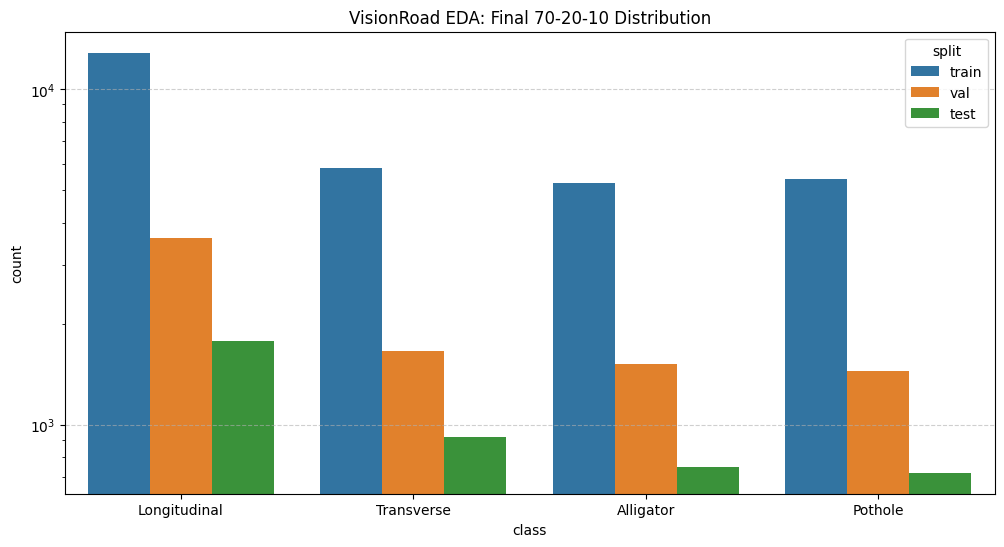

class  Alligator  Longitudinal  Pothole  Transverse
split                                              
test         746          1773      719         919
train       5264         12835     5390        5811
val         1517          3593     1445        1656


In [3]:
df_stats = pd.DataFrame(stats)
plt.figure(figsize=(12, 6))
sns.countplot(data=df_stats, x='class', hue='split', order=['Longitudinal', 'Transverse', 'Alligator', 'Pothole'])
plt.yscale('log') 
plt.title('VisionRoad EDA: Final 70-20-10 Distribution')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

print(df_stats.groupby(['split', 'class']).size().unstack(fill_value=0))

In [4]:
# Create YAML
visionroad_yaml = {
    'path': working_dir,
    'train': 'train/images', 'val': 'val/images', 'test': 'test/images',
    'names': class_names
}
with open('/kaggle/working/visionroad_v8.yaml', 'w') as f:
    yaml.dump(visionroad_yaml, f)

# Launch Training
model = YOLO('yolov8n.pt')
model.train(data='/kaggle/working/visionroad_v8.yaml', epochs=100, imgsz=640, batch=-1, device=0, project='VisionRoad_Final', name='Thesis_Adviser_Run')

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/visionroad_v8.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Thesis_Adviser_Run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=1

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d3ebddf8a40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0